# HRRP Readmissions Analyis

This is an exploratory analysis of hospital readmission rates across U.S. hospitals, using data from the Centers for Medicare & Medicaid Services (CMS) Hospital Readmissions Reduction Program (HRRP). Two CSVs are cleaned and joined: `hrrp`, which contains readmission performance data per hospital, and `hospital_info`, which adds facility characteristics such as ownership type, hospital rating, and geographic location for deeper analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hrrp = pd.read_csv('../data/raw/hrrp.csv')
hrrp.info()
hrrp.head()

<class 'pandas.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  str    
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  str    
 3   Measure Name                18330 non-null  str    
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  str    
 10  Start Date                  18330 non-null  str    
 11  End Date                    18330 non-null  str    
dtypes: float64(5), int64(1), str(6)
memory usage: 1.7 MB


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


Per data dicitonary, `footnote` column denotes reason for NaNs. Dropping NaNs so it will be irrelevant. Dropping `footnote`. Large majority of the NaNs come from `footnote` as well, so dropping this column will preserve data.

In [3]:
hrrp.drop('Footnote', axis = 1, inplace = True)
hrrp.dropna(inplace = True)

In [4]:
hospital_info = pd.read_csv('../data/raw/hospital_info.csv')
hospital_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 5432 entries, 0 to 5431
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5432 non-null   str    
 1   Facility Name                                     5432 non-null   str    
 2   Address                                           5432 non-null   str    
 3   City/Town                                         5432 non-null   str    
 4   State                                             5432 non-null   str    
 5   ZIP Code                                          5432 non-null   int64  
 6   County/Parish                                     5432 non-null   str    
 7   Telephone Number                                  5432 non-null   str    
 8   Hospital Type                                     5432 non-null   str    
 9   Hospital Ownership            

Dropping NaNs and footnote columns from `hospital_info`. Same logic as before, columns are not relevant and make up a majority of the NaNs. Dropping `Meets criteria for birthing friendly designation`. Not relevant.

In [5]:
hospital_info.isnull().sum()
drop = [
    'Meets criteria for birthing friendly designation',
    'Hospital overall rating footnote',
    'MORT Group Footnote',
    'Safety Group Footnote',
    'READM Group Footnote',
    'Pt Exp Group Footnote',
    'TE Group Footnote',
]

hospital_info.drop(drop, axis = 1, inplace = True)
hospital_info.isnull().sum()

Facility ID                              0
Facility Name                            0
Address                                  0
City/Town                                0
State                                    0
ZIP Code                                 0
County/Parish                            0
Telephone Number                         0
Hospital Type                            0
Hospital Ownership                       0
Emergency Services                       0
Hospital overall rating                  0
MORT Group Measure Count                 0
Count of Facility MORT Measures          0
Count of MORT Measures Better            0
Count of MORT Measures No Different      0
Count of MORT Measures Worse             0
Safety Group Measure Count               0
Count of Facility Safety Measures        0
Count of Safety Measures Better          0
Count of Safety Measures No Different    0
Count of Safety Measures Worse           0
READM Group Measure Count                0
Count of Fa

In [6]:
hrrp['Facility ID'] = hrrp['Facility ID'].astype('str')
hospital_info['Facility ID'] = hospital_info['Facility ID'].astype('str')
cleaned = pd.merge(hrrp, hospital_info, how = 'left', on = 'Facility ID')

In [7]:
cleaned.describe()

,Number of Discharges,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,ZIP Code
count,8037.000000,8037.000000,8037.000000,8037.000000,6685.000000
mean,290.645390,1.009088,16.569124,16.431469,43293.102019
std,270.506342,0.078521,3.702850,3.519140,24748.578064
min,27.000000,0.469800,1.908000,3.454300,1040.000000
25%,122.000000,0.964000,14.439400,14.532900,24354.000000
50%,203.000000,1.006000,17.032700,16.903200,40207.000000
75%,364.000000,1.050900,19.101400,19.054400,61764.000000
max,3672.000000,1.582700,28.164300,26.865400,99362.000000


`Excess Readmission Ratio` is closely clustered around 1, meaning that readmissions are mostly within the expected range. The small std of 0.078 indicates that most entries do not stray too far from this mean, although there are some outliers, with a max ratio of 1.58. This would be a facility worth drilling domwn on further. Next step is to visualize the column with a histogram to better conceptualize the distribution.

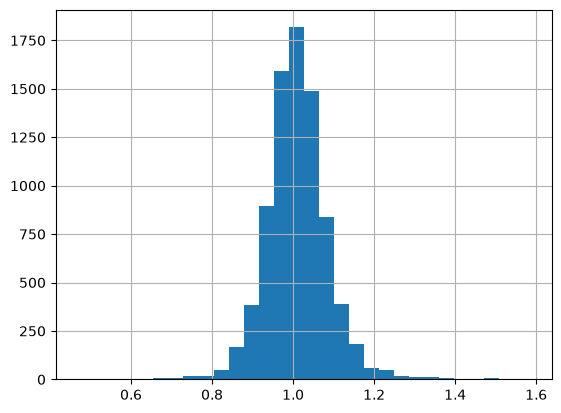

In [8]:
cleaned['Excess Readmission Ratio'].hist(bins = 30)
plt.show()

The histogram is as expected, with the data very tightly grouped around the mean. There is a slight right skew, with more outlier facilities with worse readmissions than expected. One of the more interesting relationships to explore is the relationship between `Excess Readmission Ratio` and `Measure Name`, as `Measure Name` contains the patient's reason for initial admission. We will explore this with a boxplot.

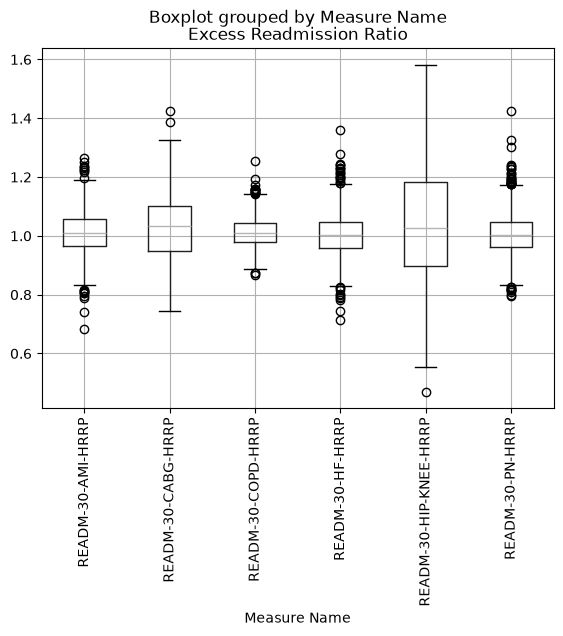

In [9]:
cleaned.boxplot(column = 'Excess Readmission Ratio', by = 'Measure Name', rot = 90)
plt.show()

Hip-Knee and CABG show the widest spread in excess readmission ratios, with Hip-Knee containing the most extreme outlier (a facility performing far better than expected, near 0.5). These facilities would be interesting to examine from a perspective of post-surgical rehabilitation protocols as well as patient compliance with treatment plans.

The next metric we will address is ownership type to see whether there are any patterns between ownership and patient outcomes.

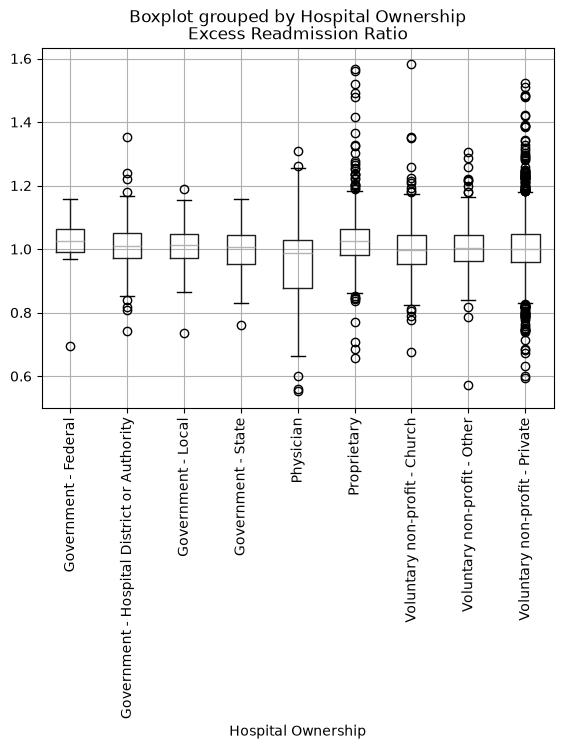

In [10]:
cleaned.boxplot(column = 'Excess Readmission Ratio', by = 'Hospital Ownership', rot = 90)
plt.show()

The results were somewhat surprising. Physician-owned facilities had the lowest median excess readmission ratio but also the widest interquartile range, indicating more variability in typical performance. Proprietary and Voluntary non-profit - Private facilities showed the largest number of outliers and widest outlier range, with some facilities performing far better than expected and others far worse, though their typical (median) performance was close to 1.0 like most other ownership types.

<Axes: title={'center': 'Excess Readmission Ratio'}, xlabel='Hospital overall rating'>

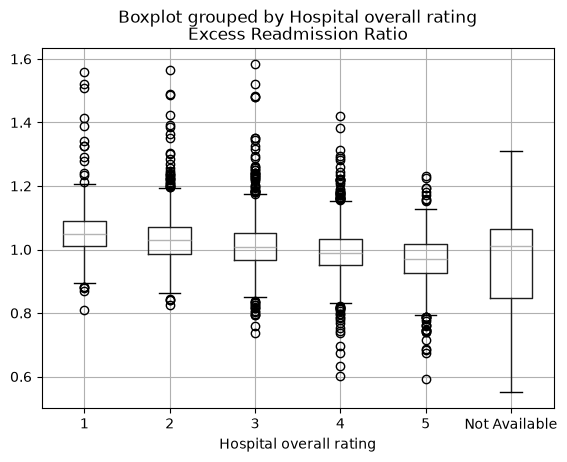

In [11]:
cleaned.boxplot(column = 'Excess Readmission Ratio', by = 'Hospital overall rating')

There is a clear trend of excess readmission ratios decreasing as star rating increases. Each rating group has a relatively tight IQR, with medians ranging from roughly 1.06 (1-star) down to 0.98 (5-star), and all groups show notable outliers in both directions. Next to examine is `Excess Readmission Ratio` by `State_x` to see if excess readmissions are affected by the state the facilities are located in.

In [12]:
cleaned.groupby('State_x')['Excess Readmission Ratio'].mean().sort_values()

State_x
ID    0.914390
UT    0.937112
MT    0.946466
OR    0.950162
ND    0.953752
ME    0.955619
SD    0.961893
WY    0.962277
KS    0.963430
DE    0.969291
CO    0.970531
WA    0.973749
VT    0.980078
MN    0.982133
IA    0.982292
NE    0.985857
NM    0.986002
MD    0.986153
DC    0.987694
HI    0.989685
WI    0.990530
NH    0.991014
VA    0.995346
NC    0.996111
OK    0.996890
RI    0.997145
IN    1.002579
AK    1.007974
CT    1.008115
MO    1.008648
TX    1.009404
AR    1.009637
MI    1.009731
SC    1.010101
AZ    1.011329
OH    1.012032
TN    1.012297
NY    1.013295
PA    1.015925
KY    1.018098
GA    1.018112
CA    1.018518
NV    1.022595
WV    1.024004
AL    1.024419
LA    1.025023
IL    1.026529
MS    1.026793
FL    1.027975
NJ    1.030998
MA    1.044375
Name: Excess Readmission Ratio, dtype: float64

Of the facilities represented in the data, those from Idaho performed the best with regards to excess readmission ratio, and Massachusetts performed the worst, although all facilities were relatively tightly grouped around 1.0. One of the interesting trends here is that the mountain-West / Great Plains states made up most of the top 10, whereas the worst performers were Eastern states

This concludes the exploratory analysis. The key findings were the inverse relationship between hospital rating and excess readmission ratio, the high variability in CABG and Hip-Knee replacement outcomes, and the pattern in which the mountain-West/Great Plains outperformed the Eastern region. These findings will inform the design of an interactive Tableau dashboard intended to help quality improvement teams identify opportunities for process improvement. 

In [15]:
cleaned.to_csv('../data/processed/hrrp_cleaned.csv', index = False)